# Tutorial 09 – BME for Categorical Data

**Package:** stamps_v3  
**MATLAB equivalent:** `BMEPROBALIBtutorial.m` (categorical section) + `STATLIBtutorial.m`  
**Dataset:** Falmagne soil dataset – 118 georeferenced soil samples, Dinant area, Belgium

---

## Learning objectives

By the end of this notebook you will be able to:

1. **Represent** categorical observations as one-hot soft-data PDFs.
2. **Compute** empirical bivariate probability tables with `probatablecalc`.
3. **Fit** a smooth probability model (kernel regression) with `probatablefit`.
4. **Map** soil types over a regular grid using three estimators:
   - **BMEcatPdf** – full Maximum Entropy BME (most rigorous, slowest).
   - **MCPcatPdf** – Maximum Conditional Probability fast approximation.
   - **HBMEcatPdf** – Hybrid BME: MCP regional prior + local BME update.
5. **Validate** each method with Leave-One-Out cross-validation (LOOCV).
6. **Interpret** posterior category probability maps.

---

## Background: categorical BME in a nutshell

Categorical BME (Christakos & Li, 1998) extends classical BME to discrete
variables. Instead of a Gaussian covariance model, spatial dependence is
encoded by a **bivariate probability table** $P(X_i = c_1, X_j = c_2 \mid h)$
that gives the joint probability of observing two categories at two locations
separated by lag $h$.

The **Maximum Entropy** principle integrates this prior dependence structure
with the observed data (hard or soft) to produce a **posterior marginal PDF**
$P(X_k = c \mid \text{data})$ at each estimation point $k$.  The MAP
(most probable category) is then taken as the point estimate.

### Workflow at a glance

```
Observations (soil codes 1–4)
      │
      ▼
One-hot PDFs  ──► probatablecalc  ──► empirical P(c1,c2|h)
                                           │
                                           ▼
                                   probatablefit  ──► smooth Pmodel(h)
                                                           │
                                                           ▼
                                    BMEcatPdf / MCPcatPdf / HBMEcatPdf
                                                           │
                                                           ▼
                                  pk[nk, nc]  ──► MAP class & probability maps
```


In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── make stamps importable ─────────────────────────────────────────────────
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# ── stamps categorical BME functions ───────────────────────────────────────
from stamps.stamps.categorical import (
    BMEcatPdf, MCPcatPdf, HBMEcatPdf,
    tune_regularization_loocv,
    loocv_categorical_points,
)
from stamps.stamps.stats.dependence import (
    probatablecalc, adaptive_bins,
    probatablefit, regularize_pmodel, alpha_empirical_bayes,
    build_pmodel, loocv_tune_pmodel,
)
from stamps.stamps.general import read_geoeas
from stamps.stamps.graph.categorical import (
    plot_categorical_map,
    plot_categorical_probmap,
    plot_categorical_class_probs,
    plot_loocv_bar,
)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
DATA_DIR = os.path.join(os.getcwd(), 'data')
print('Data directory:', DATA_DIR)

Data directory: /Users/hdragon689/Documents/MyDoc_iCloud/packages/stamps/stamps_v3/tutorials/data


## 1. Load and explore the Falmagne dataset

The file follows the **GeoEAS** format (title, column-count, column names, data).
Column 6 (`soil type`) records one of four soil classes: **1=silt-loam,
2=sandy-loam, 3=loam, 4=loamy-sand** (Dinant, Belgium classification).


In [2]:
title, col_names, data = read_geoeas(os.path.join(DATA_DIR, 'Falmagne.txt'))
print('Title   :', title)
print('Columns :', col_names)
print('Shape   :', data.shape)

east  = data[:, 0]          # easting  (m)
north = data[:, 1]          # northing (m)
sand  = data[:, 2]          # sand content (%)
silt  = data[:, 3]          # silt content (%)
clay  = data[:, 4]          # clay content (%)
code  = data[:, 5].astype(int)   # soil type 1–4

categories = np.array([1, 2, 3, 4])   # the four soil types
nc = len(categories)
n  = len(code)
print(f'\n{n} observations  |  {nc} categories: {categories}')
print('Category counts:')
for c in categories:
    print(f'  Type {c}: {np.sum(code == c):3d} ({100*np.mean(code == c):.1f}%)')

Title   : Falmagne hard data set - Granulometric composition of 118 locations in Dinant area, Belgium.
Columns : ['Easting (meters)', 'Northing (meters)', 'Sand content (%)', 'Silt content (%)', 'Clay content (%)', 'soil type (code 1 to 4)']
Shape   : (118, 6)

118 observations  |  4 categories: [1 2 3 4]
Category counts:
  Type 1:   7 (5.9%)
  Type 2:  24 (20.3%)
  Type 3:  32 (27.1%)
  Type 4:  55 (46.6%)


### 1.1 Spatial distribution of soil types

Each sampling location is coloured by its observed soil type.


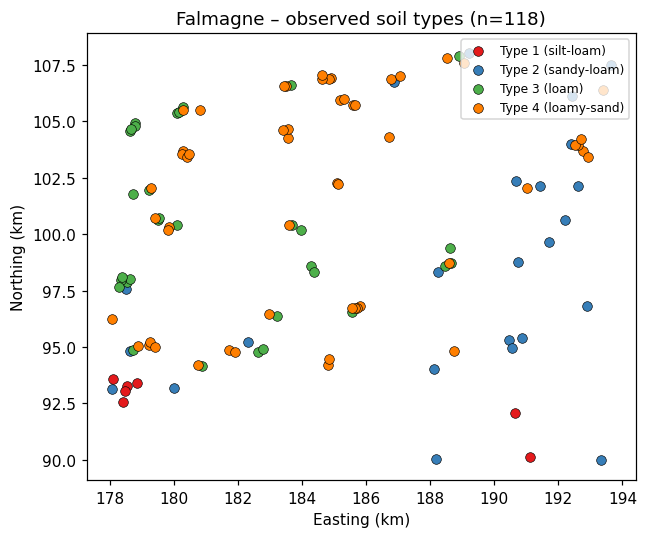

In [3]:
CMAP4 = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00']   # red / blue / green / orange
LABELS = ['Type 1 (silt-loam)', 'Type 2 (sandy-loam)',
          'Type 3 (loam)',       'Type 4 (loamy-sand)']

fig, ax = plt.subplots(figsize=(6, 5))
for i, (cat, col, lab) in enumerate(zip(categories, CMAP4, LABELS)):
    mask = code == cat
    ax.scatter(east[mask]/1e3, north[mask]/1e3,
               c=col, s=40, label=lab, edgecolors='k', linewidths=0.4, zorder=3)
ax.set_xlabel('Easting (km)');  ax.set_ylabel('Northing (km)')
ax.set_title('Falmagne – observed soil types (n=118)')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout();  plt.show()


## 2. Encoding hard data as soft PDFs

BMEcatPdf expects **soft data** – a probability mass function (PMF) over all
categories at each data location.  For **hard data** (known category),
the PMF is a one-hot vector:

$$p_s^{(i)} = [\mathbf{1}(c_i=1),\; \mathbf{1}(c_i=2),\;
               \mathbf{1}(c_i=3),\; \mathbf{1}(c_i=4)]$$

This is the degenerate (Dirac) distribution: certainty at the observed class.


In [4]:
# coordinates array
cs = np.column_stack([east, north])   # (118, 2)

# One-hot encoding: ps[i, k] = 1 if code[i] == categories[k], else 0
ps = (code[:, None] == categories[None, :]).astype(float)  # (118, 4)

print('cs shape:', cs.shape)
print('ps shape:', ps.shape)
print('First 5 rows of ps:')
print(ps[:5])
print('Corresponding codes:', code[:5])


cs shape: (118, 2)
ps shape: (118, 4)
First 5 rows of ps:
[[0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]
Corresponding codes: [3 2 4 2 3]


## 3. Empirical bivariate probability tables

`probatablecalc` estimates the joint probability
$P(X_i = c_1, X_j = c_2)$ for all category pairs as a function of the
inter-point distance $h$.  The result encodes the **spatial dependence
structure** of the categorical field – the analogue of the variogram for
continuous variables.

### Adaptive vs. uniform bins

With **uniform bins** (equal-width), short-range bins contain few pairs
(noisy estimates) while long-range bins contain many pairs but little new
information (the table is nearly at independence).

**Adaptive equal-pair bins** (`adaptive_bins`) use quantile-based edges so
every bin contains roughly the same number of point pairs.  This gives:
- **More resolution** at short distances, where dependence changes fastest.
- **More stable** long-range estimates (wider bins, more pairs).
- Reduced NaN / warning issues at extreme lags.

### Parameters
- **`coord_limit`** – edges of distance bins (metres). The first bin captures
  collocated points ($h=0$); subsequent bins cover user-defined lag classes.
- **`adaptive_bins()`** – helper that generates `coord_limit` automatically
  with methods `'equal_pairs'`, `'power_law'`, or `'log'`.
- **`chunk_size`** – memory-saving chunking (no effect on results).


Data extent: 23.8 km

--- Adaptive bins (equal-pairs, 12 bins) ---
Bin edges (km): [ 0.    2.62  4.3   5.56  6.72  7.74  8.76  9.87 10.8  12.13 13.25 14.99
 25.  ]
D shape=(13,),  P shape=(4, 4, 13),  O shape=(13,)
Pair counts per bin: [118 576 575 575 575 575 576 575 575 575 575 575 576]
  min=575  max=576  ratio=1.0

--- Uniform bins (20 bins) ---
Bin edges (km): [ 0.   0.5  1.8  3.1  4.4  5.7  6.9  8.2  9.5 10.8 12.1 13.4 14.7 16.
 17.3 18.6 19.8 21.1 22.4 23.7 25. ]
Pair counts per bin (first 8): [118 117 174 429 455 606 654 730]
  min=0  max=754  ratio=754.0


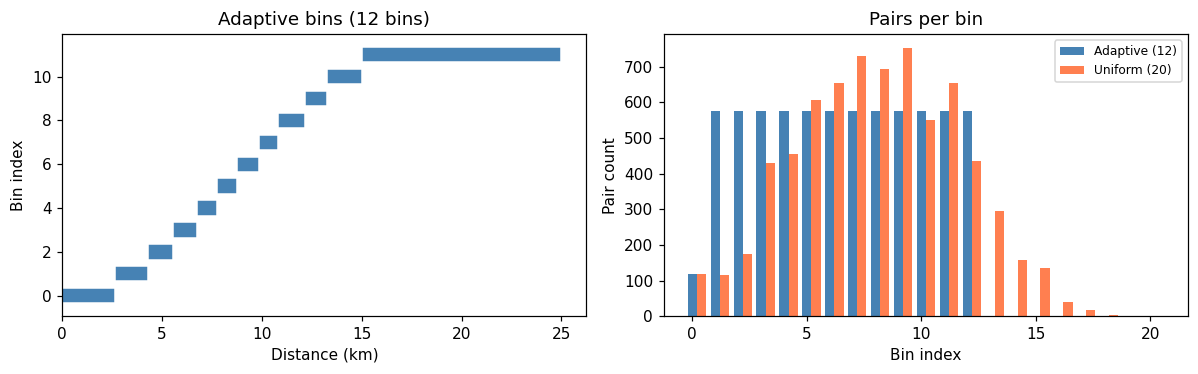

In [5]:
# ── Distance parameters ────────────────────────────────────────────────────
d_extent = np.sqrt((east.max()-east.min())**2 + (north.max()-north.min())**2)
d_max_emp  = 25_000   # 25 km  (roughly 60 % of the full extent)
n_bins     = 12        # fewer, better-filled bins
print(f'Data extent: {d_extent/1e3:.1f} km')

# ── Adaptive equal-pair bins (DEFAULT) ────────────────────────────────────
# Each bin contains approximately the same number of point pairs.
coord_limit = adaptive_bins(cs, n_bins=n_bins, d_max=d_max_emp,
                            method='equal_pairs')
print(f'\n--- Adaptive bins (equal-pairs, {n_bins} bins) ---')
print(f'Bin edges (km): {np.round(coord_limit/1e3, 2)}')

D_emp, P_emp, O_emp = probatablecalc(cs, ps, coord_limit)
print(f'D shape={D_emp.shape},  P shape={P_emp.shape},  O shape={O_emp.shape}')
print(f'Pair counts per bin: {O_emp.astype(int)}')
print(f'  min={O_emp[1:].min():.0f}  max={O_emp[1:].max():.0f}  '
      f'ratio={O_emp[1:].max()/max(O_emp[1:].min(),1):.1f}')

# ── Uniform bins (for comparison) ─────────────────────────────────────────
n_bins_uni = 20
coord_limit_uni = np.concatenate([[0], np.linspace(500, d_max_emp, n_bins_uni)])
D_uni, P_uni, O_uni = probatablecalc(cs, ps, coord_limit_uni)
print(f'\n--- Uniform bins ({n_bins_uni} bins) ---')
print(f'Bin edges (km): {np.round(coord_limit_uni/1e3, 1)}')
print(f'Pair counts per bin (first 8): {O_uni[:8].astype(int)}')
print(f'  min={O_uni[1:].min():.0f}  max={O_uni[1:].max():.0f}  '
      f'ratio={O_uni[1:].max()/max(O_uni[1:].min(),1):.1f}')

# ── Compare bin widths ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# Left: bin edges
ax = axes[0]
for i, (lo, hi) in enumerate(zip(coord_limit[:-1], coord_limit[1:])):
    ax.barh(i, (hi - lo)/1e3, left=lo/1e3, height=0.7, color='steelblue',
            edgecolor='w')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Bin index')
ax.set_title(f'Adaptive bins ({n_bins} bins)')

# Right: pair counts
ax = axes[1]
x_adapt = np.arange(len(O_emp))
x_uni   = np.arange(len(O_uni))
ax.bar(x_adapt, O_emp, width=0.4, label=f'Adaptive ({n_bins})', color='steelblue')
ax.bar(x_uni + 0.4, O_uni, width=0.4, label=f'Uniform ({n_bins_uni})', color='coral')
ax.set_xlabel('Bin index')
ax.set_ylabel('Pair count')
ax.set_title('Pairs per bin')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### 3.1 Visualise empirical probability tables

Each panel below shows how $P(X_i = c_1, X_j = c_2 \mid h)$ varies with lag
$h$ for one category pair.  **Diagonal panels** (same category) show
auto-indicator correlograms (high near $h=0$, decaying to the marginal
frequency squared).  **Off-diagonal panels** show cross-category transition
probabilities.


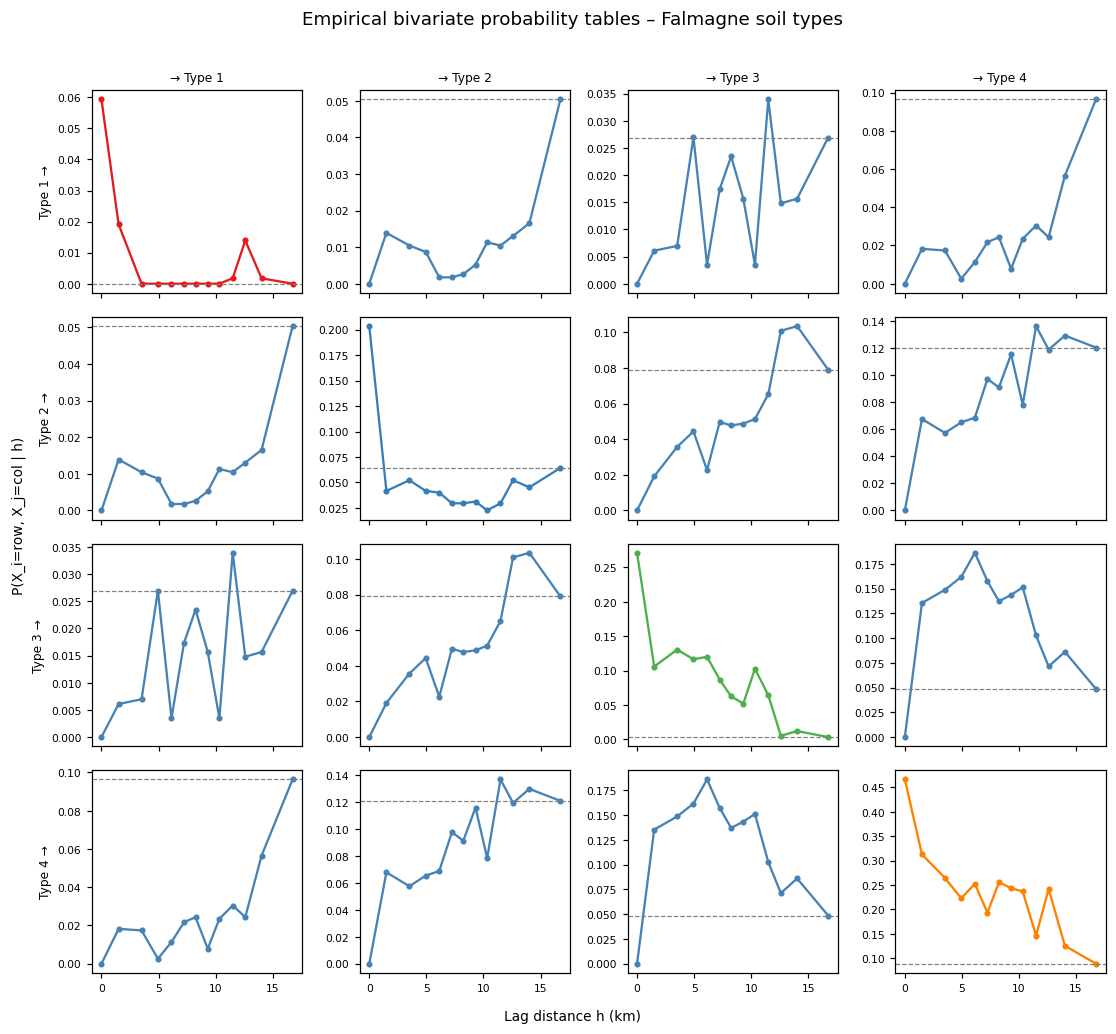

In [6]:
valid = O_emp > 0   # only bins with data
D_v   = D_emp[valid]

fig, axes = plt.subplots(nc, nc, figsize=(10, 9), sharex=True, sharey=False)
fig.suptitle('Empirical bivariate probability tables – Falmagne soil types', y=1.01)

for r in range(nc):
    for c_ in range(nc):
        ax = axes[r, c_]
        vals = P_emp[r, c_, :][valid]
        ax.plot(D_v/1e3, vals, 'o-', ms=3, color=CMAP4[r] if r == c_ else 'steelblue')
        ax.axhline(vals[-1] if len(vals) else 0, ls='--', lw=0.8, color='gray')
        if r == 0:
            ax.set_title(f'→ Type {c_+1}', fontsize=8)
        if c_ == 0:
            ax.set_ylabel(f'Type {r+1} →', fontsize=8)
        ax.tick_params(labelsize=7)

fig.text(0.5, -0.01, 'Lag distance h (km)', ha='center', fontsize=9)
fig.text(-0.01, 0.5, 'P(X_i=row, X_j=col | h)', va='center',
         rotation='vertical', fontsize=9)
plt.tight_layout();  plt.show()


## 4. Fitting a smooth probability model

`probatablefit` applies **kernel regression smoothing** (Gaussian kernel) to
the empirical tables and returns fitted values at a finer distance grid
`dfit`.  This continuous `Pmodel` is what BMEcatPdf uses at prediction time.

### Key parameters
- **`kstd`** – kernel standard deviation (bandwidth). Larger → smoother.
  A good starting value is ≈ `0.5 * d_max / n_bins`.
- **`options[1]`** – polynomial order inside the kernel window (0 = constant).
- **`options[2]`** – weight by pair count (`1` = recommended).


### 4.1 Pseudocount regularisation of `Pmodel`

`probatablefit` produces a kernel-smoothed model `Pmodel_raw`. At large lags, only a few
data pairs exist per lag class, making some bivariate cells unreliable (high noise or
exactly zero due to small-sample chance). This causes two downstream problems:

1. **ME solver instability** – the `maxentropytable` objective can diverge when bivariate
   constraints are based on near-zero counts.
2. **BF zero-suppression in HBME** – when the annular ring for the MCP prior happens to
   contain no samples of a category, the Bayes-factor for that category becomes zero,
   completely suppressing it in the HBME posterior even if local BME evidence is strong.

**Fix**: Dirichlet pseudocount regularisation shrinks each cell toward independence:

$$\tilde{P}_{c_1 c_2}^{(k)} = \frac{O^{(k)} P_{c_1 c_2}^{(k)} + \alpha\, p(c_1)p(c_2)}{O^{(k)} + \alpha}$$

The optimal $\alpha$ is found automatically by maximising the **Empirical Bayes marginal
likelihood** — a 1-D optimisation that takes less than 1 ms. Sparse lags (small $O^{(k)}$)
are regularised heavily; dense lags change very little.

In [7]:
# ── Build Pmodel from adaptive bins (default pipeline) ────────────────────
# build_pmodel wraps probatablefit + alpha_empirical_bayes + regularize_pmodel
n_fit = 80
dmodel, Pmodel, pmodel_info = build_pmodel(
    D_emp, P_emp, O_emp,
    n_fit=n_fit, n_bins=n_bins, d_max_emp=d_max_emp,
    regularize=True, verbose=True)

d_fit      = pmodel_info['d_fit']
Pmodel_raw = pmodel_info['Pmodel_raw']
alpha_opt  = pmodel_info['alpha']
kstd       = pmodel_info['kstd']

print(f'\nPmodel shape: {Pmodel.shape}  (nc × nc × n_fit)')
kstd_km = f'{kstd/1e3:.2f}' if kstd is not None else 'N/A'
print(f'kstd = {kstd_km} km   alpha = {alpha_opt:.2f}')

# ── Also build Pmodel from UNIFORM bins for comparison ────────────────────
kstd_uni = 0.5 * d_max_emp / n_bins_uni
dmodel_uni, Pmodel_uni, pmodel_info_uni = build_pmodel(
    D_uni, P_uni, O_uni,
    n_fit=n_fit, n_bins=n_bins_uni, d_max_emp=d_max_emp,
    regularize=True, verbose=True)
d_fit_uni      = pmodel_info_uni['d_fit']
Pmodel_raw_uni = pmodel_info_uni['Pmodel_raw']
alpha_uni      = pmodel_info_uni['alpha']
print(f'\nUniform Pmodel shape: {Pmodel_uni.shape}  alpha = {alpha_uni:.2f}')


[build_pmodel] fit_method=spline  monotone=True  smooth=auto  n_fit=80  d_fit=[0, 16405]
[build_pmodel] alpha=10.91  log-ML=-16474.770066262987

Pmodel shape: (4, 4, 80)  (nc × nc × n_fit)
kstd = N/A km   alpha = 10.91
[build_pmodel] fit_method=spline  monotone=True  smooth=auto  n_fit=80  d_fit=[0, 20794]
[build_pmodel] alpha=11.76  log-ML=-16473.1999412494

Uniform Pmodel shape: (4, 4, 80)  alpha = 11.76


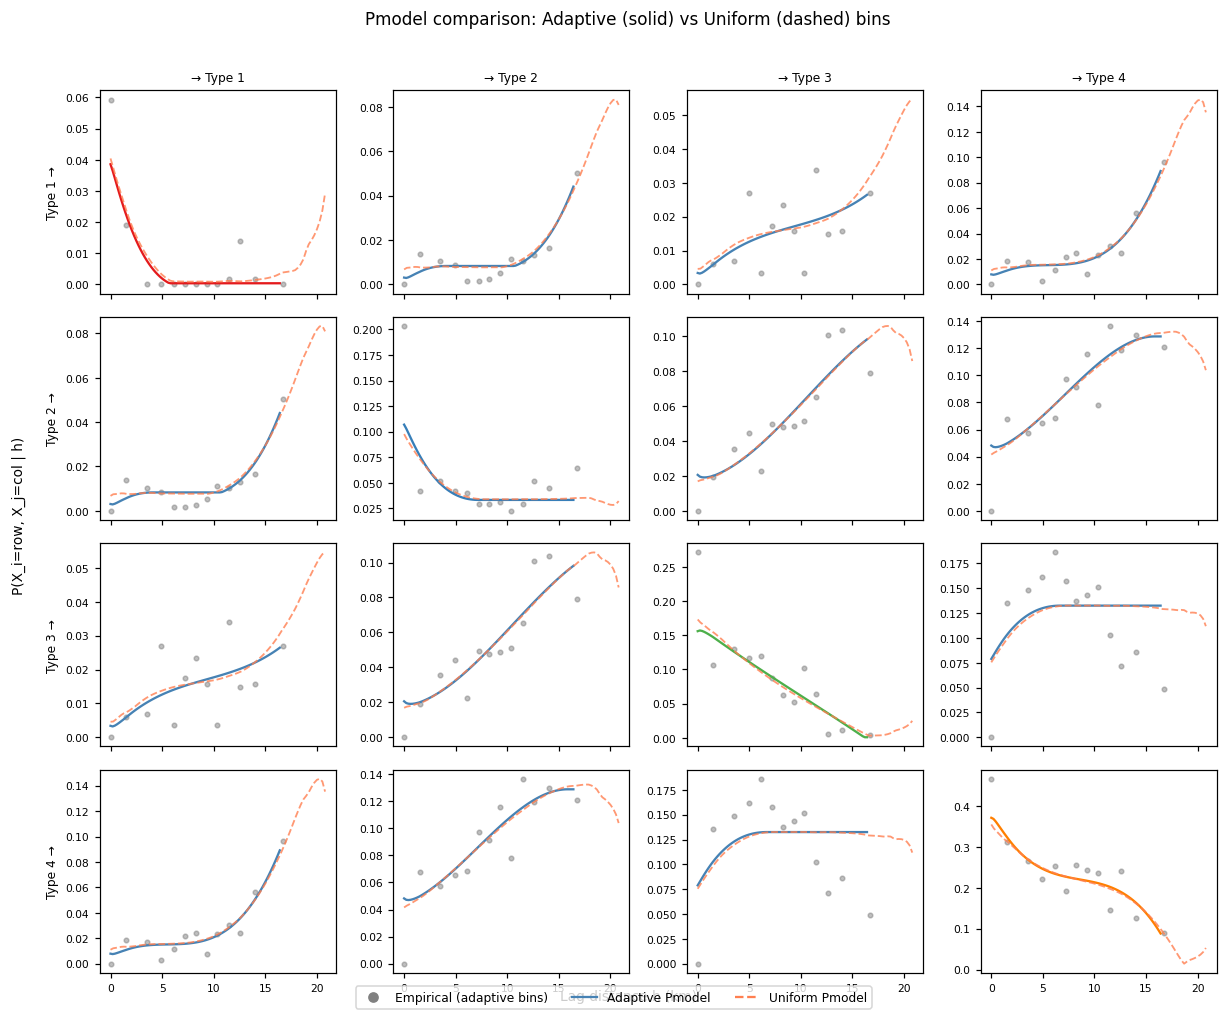

In [8]:
# ── Side-by-side Pmodel comparison: adaptive vs uniform bins ──────────────
valid = O_emp > 0;         D_v = D_emp[valid]
valid_u = O_uni > 0;       D_v_u = D_uni[valid_u]

fig, axes = plt.subplots(nc, nc, figsize=(11, 9), sharex=True)
fig.suptitle('Pmodel comparison: Adaptive (solid) vs Uniform (dashed) bins',
             y=1.01, fontsize=11)

for r in range(nc):
    for c_ in range(nc):
        ax = axes[r, c_]
        clr = CMAP4[r] if r == c_ else 'steelblue'
        # Empirical dots (adaptive)
        ax.plot(D_v/1e3, P_emp[r, c_, :][valid], 'o', ms=3,
                color='gray', alpha=0.5)
        # Adaptive Pmodel (solid)
        ax.plot(d_fit/1e3, Pmodel[r, c_, :], '-', color=clr, lw=1.5)
        # Uniform Pmodel (dashed)
        ax.plot(d_fit_uni/1e3, Pmodel_uni[r, c_, :], '--', color='coral',
                lw=1.2, alpha=0.8)
        if r == 0:
            ax.set_title(f'→ Type {c_+1}', fontsize=8)
        if c_ == 0:
            ax.set_ylabel(f'Type {r+1} →', fontsize=8)
        ax.tick_params(labelsize=7)

handles = [
    plt.Line2D([0],[0], ls='none', marker='o', color='gray',  label='Empirical (adaptive bins)'),
    plt.Line2D([0],[0], lw=1.5,               color='steelblue', label='Adaptive Pmodel'),
    plt.Line2D([0],[0], ls='--',              color='coral',   label='Uniform Pmodel'),
]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=8)
fig.text(0.5, 0.01, 'Lag distance h (km)', ha='center', fontsize=9)
fig.text(-0.01, 0.5, 'P(X_i=row, X_j=col | h)', va='center',
         rotation='vertical', fontsize=9)
plt.tight_layout();  plt.show()


## 4.2 LOOCV-based Pmodel tuning

The binning strategy and kernel bandwidth `kstd` jointly control the
quality of `Pmodel`.  Instead of guessing, we can **objectively select**
the best `(bins, kstd)` combination via Leave-One-Out Cross-Validation
(LOOCV) using `MCPcatPdf` (fast).

`loocv_tune_pmodel` runs the full pipeline for each candidate:
1. `probatablecalc` → empirical tables
2. `build_pmodel` → fit + regularise
3. LOOCV with MCPcatPdf → accuracy & mean log-likelihood

The combination that maximises **mean log-likelihood** (probabilistic
calibration) is selected as optimal.

In [9]:
# ── Neighbourhood parameters (needed by LOOCV tuning below) ───────────────
# These are also defined in the estimation section (Section 6); we set them
# here so that this cell can be executed before the grid estimation cells.
nsmax    = 8
dmax_bme = 8_000.
base_options = dict(
    show_progress  = 0,
    tol            = 1e-4,
    estimator      = 'MPL',
    model_structure= 'full',
    auto_dmax      = True,
)
import time   # used by later cells too

# ── Candidate binning strategies ───────────────────────────────────────────
cl_adapt_10 = adaptive_bins(cs, n_bins=10, d_max=d_max_emp, method='equal_pairs')
cl_adapt_12 = adaptive_bins(cs, n_bins=12, d_max=d_max_emp, method='equal_pairs')
cl_adapt_15 = adaptive_bins(cs, n_bins=15, d_max=d_max_emp, method='equal_pairs')
cl_uni_15   = np.concatenate([[0], np.linspace(500, d_max_emp, 15)])
cl_uni_20   = np.concatenate([[0], np.linspace(500, d_max_emp, 20)])

cl_candidates = [cl_adapt_10, cl_adapt_12, cl_adapt_15, cl_uni_15, cl_uni_20]
cl_labels     = ['A10', 'A12', 'A15', 'U15', 'U20']

# ── Candidate kernel bandwidths ───────────────────────────────────────────
kstd_candidates = [500., 750., 1000., 1250.]

# ── Run LOOCV grid search ─────────────────────────────────────────────────
print('=== LOOCV Pmodel tuning (MCPcatPdf) ===\n')
_t0 = time.perf_counter()

tune_results, tune_best = loocv_tune_pmodel(
    cs, ps, code, categories,
    coord_limit_candidates=cl_candidates,
    kstd_candidates=kstd_candidates,
    nsmax=nsmax, dmax=dmax_bme,
    base_options=base_options,
    method_fn=MCPcatPdf,
    n_fit=80, regularize=True, verbose=True)

_t_tune = time.perf_counter() - _t0
print(f'\nTotal tuning time: {_t_tune:.1f}s')

# ── Summary table ─────────────────────────────────────────────────────────
print(f'\n{"Label":>6s}  {"kstd":>6s}  {"Accuracy":>9s}  {"Mean LL":>9s}')
print('-' * 38)
for r in tune_results:
    print(f'{r["label"]:>18s}  {r["accuracy"]:9.3f}  {r["mean_ll"]:9.3f}')

=== LOOCV Pmodel tuning (MCPcatPdf) ===

  [1/20] bins=10 kstd=500 ...

  acc=0.610  ll=-1.848
  [2/20] bins=10 kstd=750 ...

  acc=0.610  ll=-1.848
  [3/20] bins=10 kstd=1000 ...

  acc=0.610  ll=-1.848
  [4/20] bins=10 kstd=1250 ...

  acc=0.610  ll=-1.848
  [5/20] bins=12 kstd=500 ...

...

  acc=0.508  ll=-2.114
  [17/20] bins=20 kstd=500 ...

  acc=0.517  ll=-2.084
  [18/20] bins=20 kstd=750 ...

  acc=0.517  ll=-2.084
  [19/20] bins=20 kstd=1000 ...

  acc=0.517  ll=-2.084
  [20/20] bins=20 kstd=1250 ...

  acc=0.517  ll=-2.084

  ★ Best: bins=15 kstd=500  acc=0.610  ll=-1.835

Total tuning time: 2.1s

 Label    kstd   Accuracy    Mean LL
--------------------------------------
  bins=10 kstd=500      0.610     -1.848
  bins=10 kstd=750      0.610     -1.848
 bins=10 kstd=1000      0.610     -1.848
 bins=10 kstd=1250      0.610     -1.848
  bins=12 kstd=500      0.610     -1.844
  bins=12 kstd=750      0.610     -1.844
 bins=12 kstd=1000      0.610     -1.844
 bins=12 kstd=1250      0.610     -1.844
  bins=15 kstd=500      0.610     -1.835
  bins=15 kstd=750      0.610     -1.835
 bins=15 kstd=1000      0.610     -1.835
 bins=15 kstd=1250      0.610     -1.835
  bins=15 kstd=500      0.508     -2.114
  bins=15 kstd=750      0.508     -2.114
 bins=15 kstd=1000      0.508     -2.114
 bins=15 kstd=1250      0.508     -2.114
  bins=20 kstd=500      0.517     -2.084
  bins=20 kstd=750      0.517     -2.084
 bins=20 kstd=1000      0.517     -2.084
 bins=20 kstd=1250      0.517     -2.084


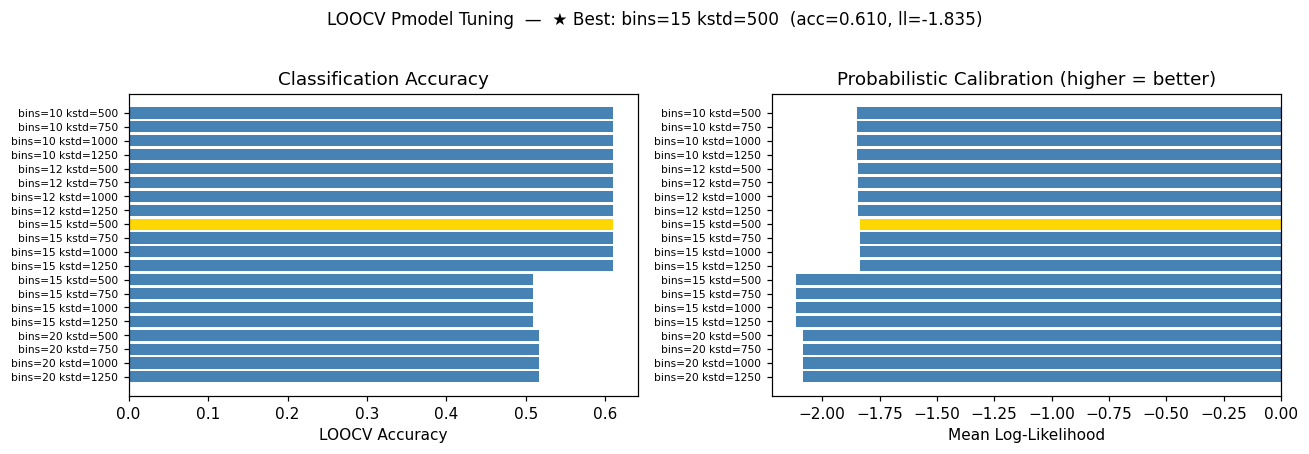

In [10]:
# ── Visualise LOOCV tuning results ─────────────────────────────────────────
labels_all = [r['label'] for r in tune_results]
accs_all   = [r['accuracy'] for r in tune_results]
lls_all    = [r['mean_ll']  for r in tune_results]
best_idx   = lls_all.index(max(lls_all))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
ax = axes[0]
colors = ['gold' if i == best_idx else 'steelblue' for i in range(len(labels_all))]
ax.barh(range(len(labels_all)), accs_all, color=colors)
ax.set_yticks(range(len(labels_all)))
ax.set_yticklabels(labels_all, fontsize=7)
ax.set_xlabel('LOOCV Accuracy')
ax.set_title('Classification Accuracy')
ax.invert_yaxis()

# Mean Log-Likelihood
ax = axes[1]
ax.barh(range(len(labels_all)), lls_all, color=colors)
ax.set_yticks(range(len(labels_all)))
ax.set_yticklabels(labels_all, fontsize=7)
ax.set_xlabel('Mean Log-Likelihood')
ax.set_title('Probabilistic Calibration (higher = better)')
ax.invert_yaxis()

plt.suptitle(f'LOOCV Pmodel Tuning  —  ★ Best: {tune_best["label"]}  '
             f'(acc={tune_best["accuracy"]:.3f}, ll={tune_best["mean_ll"]:.3f})',
             y=1.02, fontsize=11)
plt.tight_layout();  plt.show()

## 5. Build the estimation grid

We create a regular `nkx × nky` grid covering the data extent.


In [11]:
nkx, nky = 50, 50
x_grid = np.linspace(east.min(),  east.max(),  nkx)
y_grid = np.linspace(north.min(), north.max(), nky)
XX, YY = np.meshgrid(x_grid, y_grid)
ck = np.column_stack([XX.ravel(), YY.ravel()])   # (nk, 2)
nk = ck.shape[0]
print(f'Estimation grid: {nkx} × {nky} = {nk} nodes')


Estimation grid: 50 × 50 = 2500 nodes


## 6. Neighbourhood parameters

| Parameter | Description |
|-----------|-------------|
| `nsmax`   | Max soft-data neighbours to include in the ME table |
| `dmax`    | Maximum search radius (metres) |

**Guideline:** `dmax` should cover the correlation range of the fitted
probability model (~5–15 km for this dataset), and `nsmax ≤ 10` keeps
the ME optimisation tractable.


In [12]:
nsmax    = 8        # max neighbours in the ME table
# Fix 1: dmax_bme = effective correlation range (~8 km) so the local BME
# neighbourhood only contains spatially-correlated data.  Previously 15 km
# caused decorrelated far-away data to contaminate the ME table.
dmax_bme = 8_000.   # 8 km ≈ effective correlation range (from Pmodel)

# Estimator options (shared by all three methods)
base_options = dict(
    show_progress  = 0,
    tol            = 1e-4,
    estimator      = 'MPL',    # Maximum Pseudo-Likelihood (fast & stable)
    model_structure= 'full',   # use all (nsmax choose 2) bivariate constraints
    auto_dmax      = True,     # Fix 4: auto-detect dmax from Pmodel effective range
)
print('nsmax:', nsmax, '  dmax:', dmax_bme/1e3, 'km')
print('Estimator options:', base_options)


nsmax: 8   dmax: 8.0 km
Estimator options: {'show_progress': 0, 'tol': 0.0001, 'estimator': 'MPL', 'model_structure': 'full', 'auto_dmax': True}


## 7. BME categorical estimation (BMEcatPdf)

**BMEcatPdf** is the rigorous Bayesian Maximum Entropy estimator.  For each
estimation node it:

1. Finds the `nsmax` nearest data points within `dmax`.
2. Builds the bivariate probability constraints from `Pmodel`.
3. Solves a Maximum Entropy optimisation to get the prior multivariate PMF
   $f(X_k, X_{s_1}, \dots, X_{s_m})$.
4. Multiplies by the observed soft data PDFs to get the unnormalised
   posterior, then marginalises over the neighbours to obtain
   $P(X_k = c \mid \text{data})$.


In [13]:
import time

bme_options = {**base_options, 'show_progress': 1}

print(f'Running BMEcatPdf on {nk} nodes ...')
t0 = time.perf_counter()
pk_bme = BMEcatPdf(ck, cs, ps, dmodel, Pmodel,
                   nsmax=nsmax, dmax=dmax_bme, options=bme_options)
t_bme = time.perf_counter() - t0

print(f'\nBMEcatPdf finished in {t_bme:.1f}s  ({t_bme/nk*1000:.1f} ms/node)')
print('pk_bme shape:', pk_bme.shape)

# MAP estimate: category with highest posterior probability
map_bme = categories[np.argmax(pk_bme, axis=1)]   # (nk,)
# Maximum posterior probability (confidence)
maxp_bme = pk_bme.max(axis=1)
print('BME MAP class distribution:', {c: int(np.sum(map_bme == c)) for c in categories})


Running BMEcatPdf on 2500 nodes ...
1/2500
2/2500
3/2500
4/2500
5/2500
6/2500


7/2500
8/2500
9/2500
10/2500
11/2500
12/2500
13/2500
14/2500
15/2500
16/2500
17/2500
18/2500
19/2500
20/2500
21/2500
22/2500


23/2500
24/2500
25/2500
26/2500
27/2500
28/2500
29/2500


30/2500
31/2500
32/2500
33/2500
34/2500
35/2500
36/2500
37/2500
38/2500
39/2500
40/2500
41/2500
42/2500
43/2500
44/2500
45/2500
46/2500


47/2500
48/2500
49/2500
50/2500
51/2500
52/2500
53/2500


...

2447/2500
2448/2500
2449/2500
2450/2500
2451/2500
2452/2500
2453/2500
2454/2500
2455/2500
2456/2500
2457/2500
2458/2500


2459/2500
2460/2500
2461/2500
2462/2500
2463/2500
2464/2500
2465/2500
2466/2500
2467/2500
2468/2500
2469/2500


2470/2500
2471/2500
2472/2500
2473/2500
2474/2500
2475/2500
2476/2500
2477/2500
2478/2500
2479/2500
2480/2500
2481/2500


2482/2500
2483/2500
2484/2500
2485/2500
2486/2500
2487/2500
2488/2500
2489/2500
2490/2500
2491/2500
2492/2500


2493/2500
2494/2500
2495/2500
2496/2500
2497/2500
2498/2500
2499/2500
2500/2500

BMEcatPdf finished in 21.3s  (8.5 ms/node)
pk_bme shape: (2500, 4)
BME MAP class distribution: {np.int64(1): 435, np.int64(2): 5, np.int64(3): 58, np.int64(4): 2002}


## 8. MCP fast approximation (MCPcatPdf)

**MCPcatPdf** (Maximum Conditional Probability) approximates the BME posterior
by assuming that the data points are **conditionally independent given
the estimation point**.  This avoids the ME optimisation and is therefore
orders of magnitude faster, at the cost of some accuracy when data are
spatially clustered.


In [14]:
mcp_options = {**base_options, 'show_progress': 0}

print(f'Running MCPcatPdf on {nk} nodes ...')
t0 = time.perf_counter()
pk_mcp = MCPcatPdf(ck, cs, ps, dmodel, Pmodel,
                   nsmax=nsmax, dmax=dmax_bme, options=mcp_options)
t_mcp = time.perf_counter() - t0

print(f'MCPcatPdf finished in {t_mcp:.1f}s  ({t_mcp/nk*1000:.1f} ms/node)')
map_mcp  = categories[np.argmax(pk_mcp, axis=1)]
maxp_mcp = pk_mcp.max(axis=1)
print('MCP speed-up vs BME: ×{:.0f}'.format(t_bme / t_mcp if t_mcp > 0 else np.inf))


Running MCPcatPdf on 2500 nodes ...


MCPcatPdf finished in 0.4s  (0.2 ms/node)
MCP speed-up vs BME: ×52


## 9. Hybrid BME (HBMEcatPdf)

**HBMEcatPdf** implements a two-step hybrid approach:

1. **Step 1 — regional prior (MCP):** `MCPcatPdf` is called with `nsmax_total`
   neighbours, restricted to `dmax_mcp`, to build a spatially varying soft prior
   that captures the regional category trend.
2. **Step 2 — local update (BME):** `BMEcatPdf` is called with only the `nsmax`
   closest neighbours, using the MCP prior. The full ME table (all `nsmax` pairs)
   is solved exactly, accounting for local spatial redundancy.

### ⚠️  Critical parameter: `nsmax_total` and `dmax_mcp`

At distances **beyond the covariance correlation range** the bivariate probability
table factorises to the independence product $P(c')\cdot P(c)$.  Each such
out-of-range neighbour adds $\log P(c)$ to the MCP log-posterior, causing:

$$\log p(X_0{=}c) \approx \log P(c) \quad\text{(global marginal, same everywhere)}$$

**If `nsmax_total` is too large (e.g. 40 out of 118 data points), the MCP prior
degenerates to the global category frequencies at every estimation location, making
the final HBME map nearly flat.**

**Rule of thumb:**
- Set `dmax_mcp` ≈ the covariance correlation range (here ~8 km from the fitted model).
- Set `nsmax_total` ≈ 2–3 × `nsmax` (i.e. the expected number of data points
  within `dmax_mcp`).


In [15]:
# Fix 1: dmax_mcp > dmax_bme so the annular ring (dmax_bme, dmax_mcp] is
# non-empty.  Data between 8 km and 15 km are used for the MCP prior only;
# the local BME update (Step 2) uses the 8 km zone exclusively.
# auto_dmax_mcp is disabled because we set the radii explicitly.
dmax_mcp    = 15_000.  # MCP prior ring: data at 8–15 km (Fix 1)
nsmax_total = 15       # max neighbours in the MCP prior ring

hbme_options = {**base_options,
                'nsmax_total'  : nsmax_total,
                'dmax_mcp'     : dmax_mcp,
                'auto_dmax_mcp': False,       # Fix 1: explicit radii, no auto-detect
                'show_progress': 0}

print(f'Running HBMEcatPdf on {nk} nodes ...')
print(f'  nsmax={nsmax} (BME step)  nsmax_total={nsmax_total} (MCP prior step)')
print(f'  dmax_bme={dmax_bme/1e3:.0f} km   dmax_mcp={dmax_mcp/1e3:.0f} km')
t0 = time.perf_counter()
pk_hbme = HBMEcatPdf(ck, cs, ps, dmodel, Pmodel,
                     nsmax=nsmax, dmax=dmax_bme, options=hbme_options)
t_hbme = time.perf_counter() - t0

print(f'HBMEcatPdf finished in {t_hbme:.1f}s  ({t_hbme/nk*1000:.1f} ms/node)')
map_hbme  = categories[np.argmax(pk_hbme, axis=1)]
maxp_hbme = pk_hbme.max(axis=1)


Running HBMEcatPdf on 2500 nodes ...
  nsmax=8 (BME step)  nsmax_total=15 (MCP prior step)
  dmax_bme=8 km   dmax_mcp=15 km


HBMEcatPdf finished in 22.6s  (9.0 ms/node)


## 10. MAP class maps

Each cell is coloured by its **most probable category** under each method.
The data locations are overlaid as black-bordered circles.


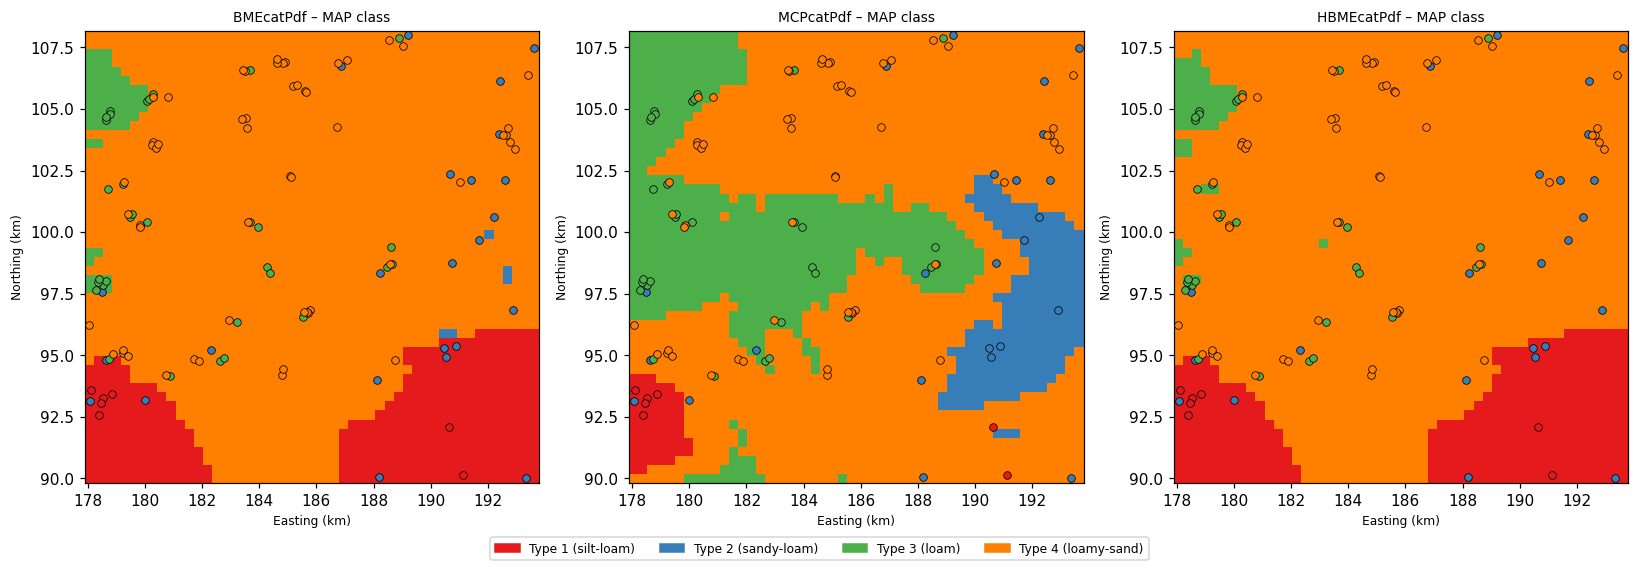

In [16]:
fig, axes = plot_categorical_map(
    XX, YY,
    [map_bme, map_mcp, map_hbme],
    ['BMEcatPdf – MAP class', 'MCPcatPdf – MAP class', 'HBMEcatPdf – MAP class'],
    list(categories), LABELS, CMAP4,
    cs_data=cs, code_data=code,
    figsize=(15, 5),
)
plt.show()

## 11. Posterior uncertainty maps

The **maximum posterior probability** (i.e. the probability assigned to the
MAP class) measures classification confidence.  Values near 0.25 (uniform
over 4 classes) indicate high uncertainty; values near 1 indicate near-certain
classification.


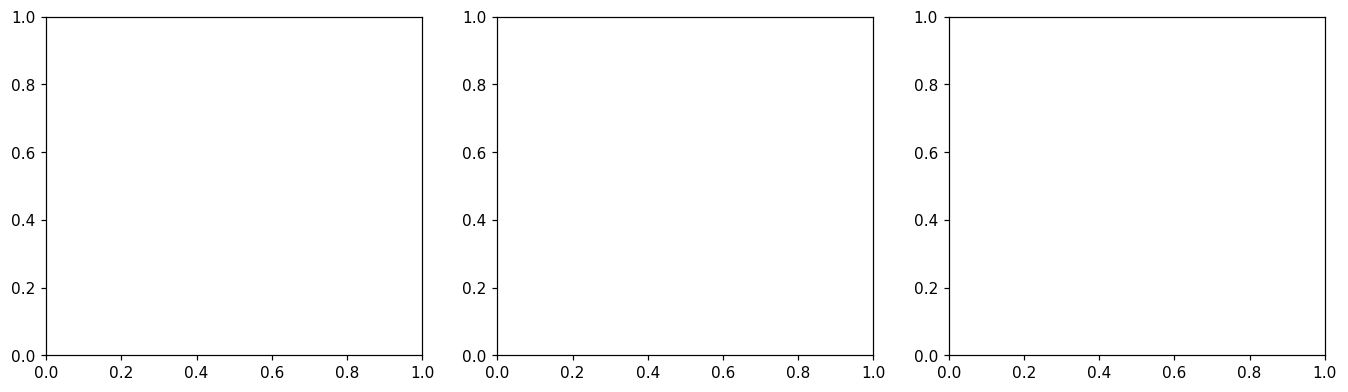

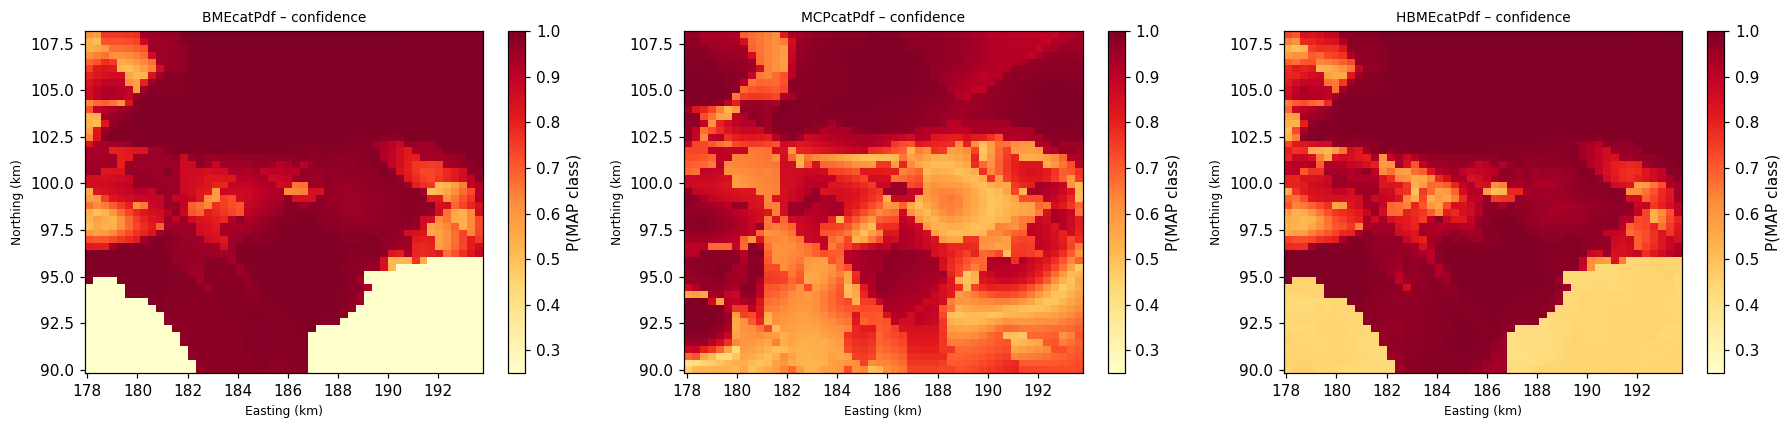

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_categorical_probmap(
    XX, YY,
    [maxp_bme, maxp_mcp, maxp_hbme],
    ['BMEcatPdf – confidence', 'MCPcatPdf – confidence', 'HBMEcatPdf – confidence'],
    vmin=1/nc, vmax=1.0,
)
plt.show()

## 12. Individual category probability maps (BMEcatPdf)

The full posterior PMF gives the probability of **each** category at every
grid node — not just the MAP class.  These "probability of occurrence" maps
are useful for uncertainty propagation and risk assessment.


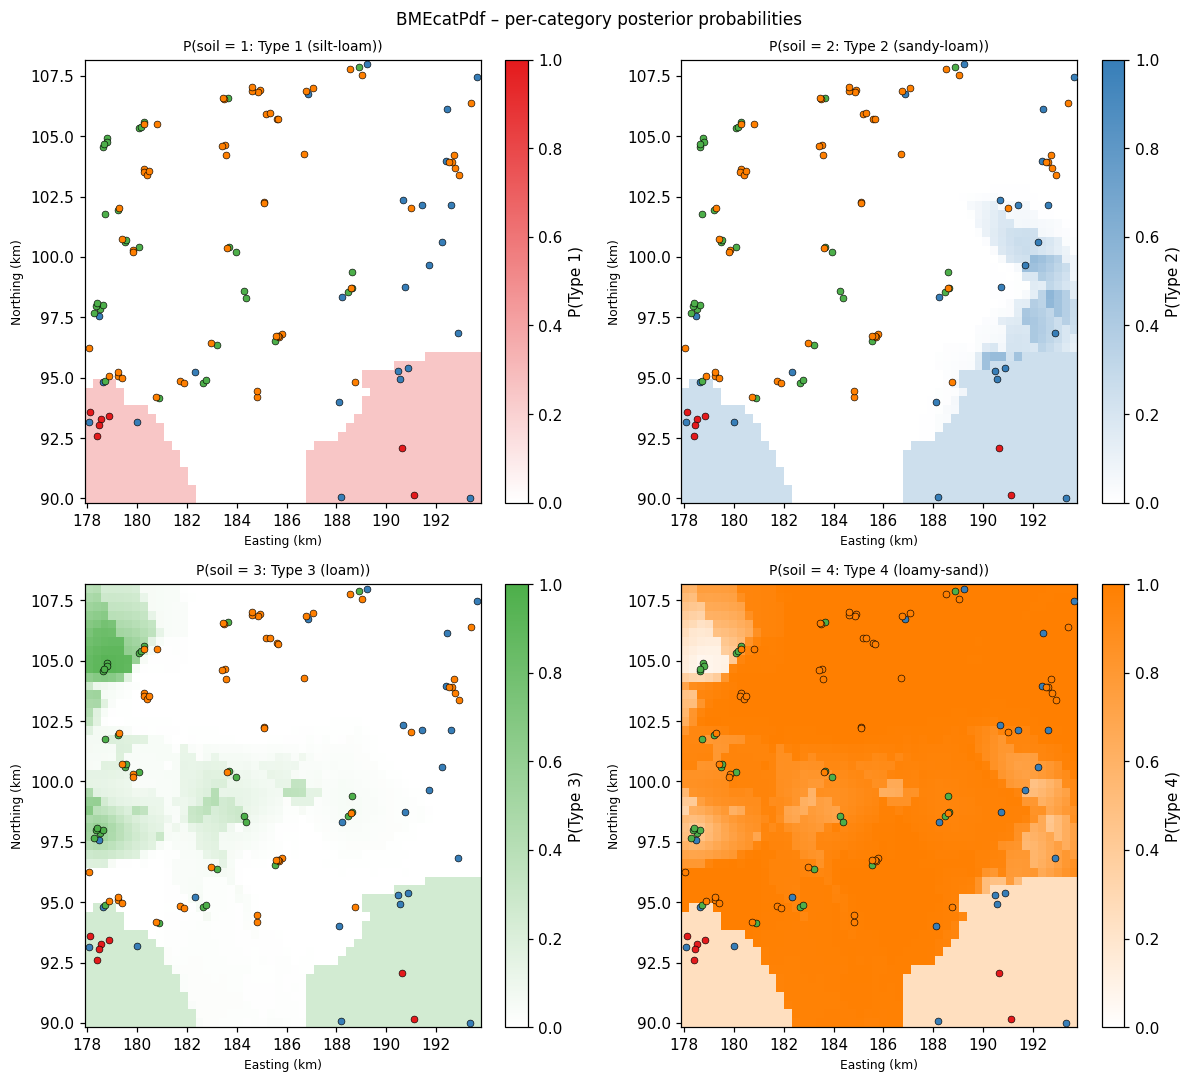

In [18]:
plot_categorical_class_probs(
    XX, YY, pk_bme,
    list(categories), LABELS, CMAP4,
    cs_data=cs, code_data=code,
    suptitle='BMEcatPdf – per-category posterior probabilities',
)
plt.show()

## 13. Leave-One-Out Cross-Validation (LOOCV)

We evaluate predictive accuracy by predicting each data point using all
remaining points, then comparing the predicted MAP class with the true class.

**Metrics used:**
- **Accuracy** – fraction of correctly predicted MAP classes.
- **Mean log-likelihood** – $\frac{1}{n}\sum_i \log P(\hat{X}_i = c_i)$;
  higher is better; measures probabilistic calibration.


In [19]:
print('Running LOOCV for BMEcatPdf  ...')
res_bme = loocv_categorical_points(
    BMEcatPdf, cs, ps, dmodel, Pmodel,
    nsmax=nsmax, dmax=dmax_bme, categories=categories,
    options=base_options)
acc_bme, ll_bme = res_bme['accuracy'], res_bme['mean_log_likelihood']
print(f'  BME  – Accuracy: {acc_bme:.3f}  |  Mean log-likelihood: {ll_bme:.3f}')

print('Running LOOCV for MCPcatPdf  ...')
res_mcp = loocv_categorical_points(
    MCPcatPdf, cs, ps, dmodel, Pmodel,
    nsmax=nsmax, dmax=dmax_bme, categories=categories,
    options=base_options)
acc_mcp, ll_mcp = res_mcp['accuracy'], res_mcp['mean_log_likelihood']
print(f'  MCP  – Accuracy: {acc_mcp:.3f}  |  Mean log-likelihood: {ll_mcp:.3f}')

print('Running LOOCV for HBMEcatPdf ...')
hbme_loocv_opts = {**base_options,
                   'nsmax_total'  : nsmax_total,
                   'dmax_mcp'     : dmax_mcp,
                   'auto_dmax_mcp': False}
res_hbme = loocv_categorical_points(
    HBMEcatPdf, cs, ps, dmodel, Pmodel,
    nsmax=nsmax, dmax=dmax_bme, categories=categories,
    options=hbme_loocv_opts)
acc_hbme, ll_hbme = res_hbme['accuracy'], res_hbme['mean_log_likelihood']

Running LOOCV for BMEcatPdf  ...


  BME  – Accuracy: 0.534  |  Mean log-likelihood: -2.384
Running LOOCV for MCPcatPdf  ...
  MCP  – Accuracy: 0.610  |  Mean log-likelihood: -1.844
Running LOOCV for HBMEcatPdf ...


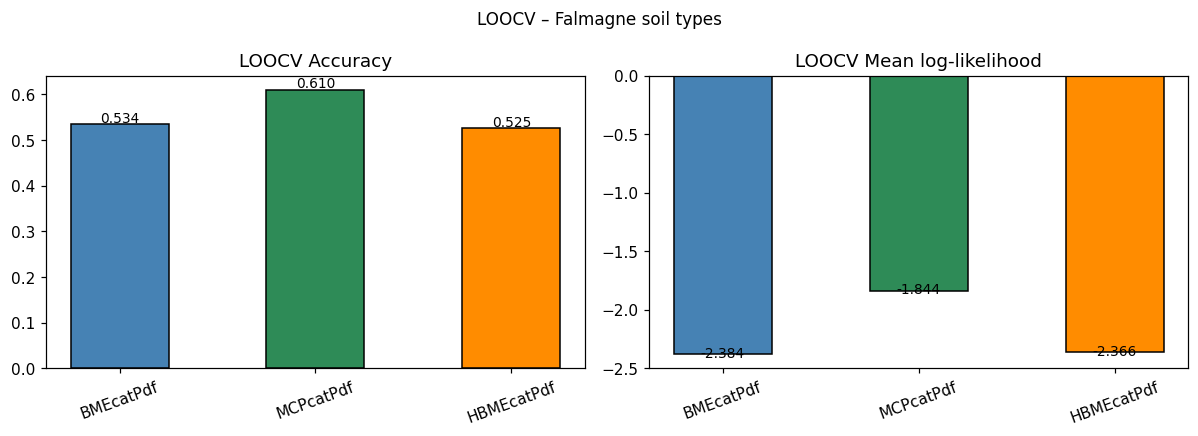


Summary table:
    Method  LOOCV Accuracy  Mean Log-Lik
 BMEcatPdf        0.533898     -2.384152
 MCPcatPdf        0.610169     -1.843524
HBMEcatPdf        0.525424     -2.365634


In [20]:
methods    = ['BMEcatPdf', 'MCPcatPdf', 'HBMEcatPdf']
accuracies = [acc_bme,  acc_mcp,  acc_hbme]
log_liks_  = [ll_bme,   ll_mcp,   ll_hbme]

plot_loocv_bar(methods, accuracies, log_liks_, suptitle='LOOCV – Falmagne soil types')
plt.show()

print('\nSummary table:')
df_res = pd.DataFrame({'Method': methods,
                        'LOOCV Accuracy': accuracies,
                        'Mean Log-Lik' : log_liks_})
print(df_res.to_string(index=False))

## 13.1 Pmodel comparison – impact on estimation accuracy

We have three Pmodel variants, each reflecting a different strategy for
empirical probability table estimation:

| Tag | Strategy | Description |
|-----|----------|-------------|
| **Adaptive** | Default adaptive (equal-pair) bins | Quantile-based edges → equal pairs per bin. Denser at short lags where dependence changes fastest. |
| **Uniform** | Classic uniform-width bins | Equal-width distance classes. Familiar, but noisy at short lags and wasteful at long lags. |
| **LOOCV-tuned** | Grid-search over bins × kstd | Objectively selects the (bins, kstd) combination that maximises LOOCV mean log-likelihood. |

Below we run **MCPcatPdf LOOCV** with each Pmodel to isolate the effect of
the probability model on classification accuracy and probabilistic calibration,
and then re-run all three estimators (BME, MCP, HBME) with the **best Pmodel**
to see whether the improvement carries over.

In [21]:
# ── Run MCPcatPdf LOOCV with each Pmodel variant ──────────────────────────
pmodel_variants = {
    'Adaptive bins (default)': (dmodel, Pmodel),
    'Uniform bins'           : (dmodel_uni, Pmodel_uni),
    f'LOOCV-tuned ({tune_best["label"]})' : (tune_best['dmodel'], tune_best['Pmodel']),
}

mcp_loocv_results = {}
opts_quiet = {**base_options, 'show_progress': 0}

for label, (dm_v, pm_v) in pmodel_variants.items():
    print(f'LOOCV MCPcatPdf — {label} ...', end=' ', flush=True)
    t0 = time.perf_counter()
    res_v = loocv_categorical_points(
        MCPcatPdf, cs, ps, dm_v, pm_v,
        nsmax=nsmax, dmax=dmax_bme, categories=categories,
        options=opts_quiet)
    dt = time.perf_counter() - t0
    mcp_loocv_results[label] = dict(
        accuracy=res_v['accuracy'], mean_ll=res_v['mean_log_likelihood'], time=dt)
    print(f'acc={res_v["accuracy"]:.3f}  ll={res_v["mean_log_likelihood"]:.3f}  ({dt:.1f}s)')

print('\n' + '='*65)
print(f'{"Pmodel variant":<35s}  {"Accuracy":>9s}  {"Mean LL":>9s}')
print('-'*65)
for lab, r in mcp_loocv_results.items():
    star = ' ★' if r['mean_ll'] == max(v['mean_ll'] for v in mcp_loocv_results.values()) else ''
    print(f'{lab:<35s}  {r["accuracy"]:9.3f}  {r["mean_ll"]:9.3f}{star}')
print('='*65)

LOOCV MCPcatPdf — Adaptive bins (default) ... 

acc=0.610  ll=-1.844  (0.0s)
LOOCV MCPcatPdf — Uniform bins ... 

acc=0.517  ll=-2.084  (0.0s)
LOOCV MCPcatPdf — LOOCV-tuned (bins=15 kstd=500) ... 

acc=0.610  ll=-1.835  (0.0s)

Pmodel variant                        Accuracy    Mean LL
-----------------------------------------------------------------
Adaptive bins (default)                  0.610     -1.844
Uniform bins                             0.517     -2.084
LOOCV-tuned (bins=15 kstd=500)           0.610     -1.835 ★


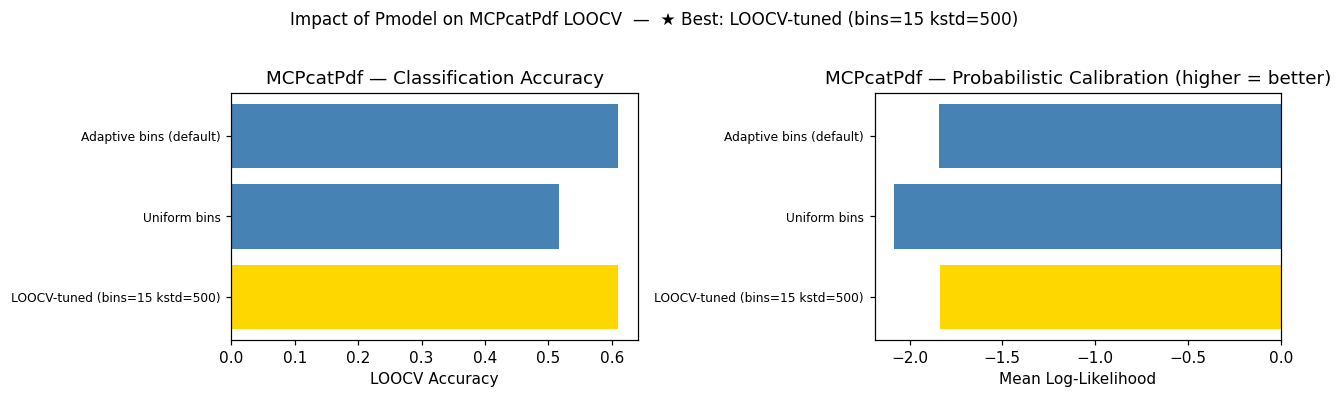

In [22]:
# ── Visualise Pmodel comparison (MCPcatPdf LOOCV) ────────────────────────
labels_pm  = list(mcp_loocv_results.keys())
accs_pm    = [mcp_loocv_results[l]['accuracy'] for l in labels_pm]
lls_pm     = [mcp_loocv_results[l]['mean_ll']  for l in labels_pm]
best_pm    = labels_pm[lls_pm.index(max(lls_pm))]
bar_c      = ['gold' if l == best_pm else 'steelblue' for l in labels_pm]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

ax = axes[0]
ax.barh(range(len(labels_pm)), accs_pm, color=bar_c)
ax.set_yticks(range(len(labels_pm)));  ax.set_yticklabels(labels_pm, fontsize=8)
ax.set_xlabel('LOOCV Accuracy');  ax.set_title('MCPcatPdf — Classification Accuracy')
ax.invert_yaxis()

ax = axes[1]
ax.barh(range(len(labels_pm)), lls_pm, color=bar_c)
ax.set_yticks(range(len(labels_pm)));  ax.set_yticklabels(labels_pm, fontsize=8)
ax.set_xlabel('Mean Log-Likelihood')
ax.set_title('MCPcatPdf — Probabilistic Calibration (higher = better)')
ax.invert_yaxis()

plt.suptitle(f'Impact of Pmodel on MCPcatPdf LOOCV  —  ★ Best: {best_pm}',
             y=1.02, fontsize=11)
plt.tight_layout();  plt.show()

### Full estimator comparison with the LOOCV-tuned Pmodel

We re-run **BMEcatPdf**, **MCPcatPdf**, and **HBMEcatPdf** LOOCV using the
LOOCV-tuned Pmodel and compare with the default adaptive-bins results from
Section 12.  This tells us whether the Pmodel improvement found by the grid
search translates into a real gain for every estimator.

In [23]:
# ── LOOCV with LOOCV-tuned Pmodel for all three methods ───────────────────
dmodel_tuned = tune_best['dmodel']
Pmodel_tuned = tune_best['Pmodel']

print(f'Using LOOCV-tuned Pmodel: {tune_best["label"]}')
print(f'  dmodel range: [0, {dmodel_tuned[-1]/1e3:.1f}] km   shape: {Pmodel_tuned.shape}\n')

opts_quiet = {**base_options, 'show_progress': 0}

print('LOOCV BMEcatPdf  (tuned Pmodel) ...', flush=True)
res_bme_t = loocv_categorical_points(
    BMEcatPdf, cs, ps, dmodel_tuned, Pmodel_tuned,
    nsmax=nsmax, dmax=dmax_bme, categories=categories, options=base_options)
acc_bme_t, ll_bme_t = res_bme_t['accuracy'], res_bme_t['mean_log_likelihood']
print(f'  Accuracy: {acc_bme_t:.3f}  |  Mean LL: {ll_bme_t:.3f}')

print('LOOCV MCPcatPdf  (tuned Pmodel) ...', flush=True)
res_mcp_t = loocv_categorical_points(
    MCPcatPdf, cs, ps, dmodel_tuned, Pmodel_tuned,
    nsmax=nsmax, dmax=dmax_bme, categories=categories, options=opts_quiet)
acc_mcp_t, ll_mcp_t = res_mcp_t['accuracy'], res_mcp_t['mean_log_likelihood']
print(f'  Accuracy: {acc_mcp_t:.3f}  |  Mean LL: {ll_mcp_t:.3f}')

print('LOOCV HBMEcatPdf (tuned Pmodel) ...', flush=True)
hbme_loocv_opts_t = {**base_options,
                     'nsmax_total'  : nsmax_total,
                     'dmax_mcp'     : dmax_mcp,
                     'auto_dmax_mcp': False}
res_hbme_t = loocv_categorical_points(
    HBMEcatPdf, cs, ps, dmodel_tuned, Pmodel_tuned,
    nsmax=nsmax, dmax=dmax_bme, categories=categories, options=hbme_loocv_opts_t)
acc_hbme_t, ll_hbme_t = res_hbme_t['accuracy'], res_hbme_t['mean_log_likelihood']
print(f'  Accuracy: {acc_hbme_t:.3f}  |  Mean LL: {ll_hbme_t:.3f}')

print('\n' + '='*72)
print(f'{"Method":<12s}  {"Pmodel":<15s}  {"Accuracy":>9s}  {"Mean LL":>9s}  {"Δ acc":>7s}  {"Δ LL":>7s}')
print('-'*72)
rows = [
    ('BMEcatPdf',  'Adaptive',    acc_bme,    ll_bme,    None, None),
    ('BMEcatPdf',  'LOOCV-tuned', acc_bme_t,  ll_bme_t,  acc_bme_t  - acc_bme,   ll_bme_t  - ll_bme),
    ('MCPcatPdf',  'Adaptive',    acc_mcp,    ll_mcp,    None, None),
    ('MCPcatPdf',  'LOOCV-tuned', acc_mcp_t,  ll_mcp_t,  acc_mcp_t  - acc_mcp,   ll_mcp_t  - ll_mcp),
    ('HBMEcatPdf', 'Adaptive',    acc_hbme,   ll_hbme,   None, None),
    ('HBMEcatPdf', 'LOOCV-tuned', acc_hbme_t, ll_hbme_t, acc_hbme_t - acc_hbme,  ll_hbme_t - ll_hbme),
]
for method, pm, acc, ll, da, dl in rows:
    da_s = f'{da:+.3f}' if da is not None else '  —  '
    dl_s = f'{dl:+.3f}' if dl is not None else '  —  '
    print(f'{method:<12s}  {pm:<15s}  {acc:9.3f}  {ll:9.3f}  {da_s:>7s}  {dl_s:>7s}')
print('='*72)

Using LOOCV-tuned Pmodel: bins=15 kstd=500
  dmodel range: [0, 16.8] km   shape: (4, 4, 80)

LOOCV BMEcatPdf  (tuned Pmodel) ...


  Accuracy: 0.534  |  Mean LL: -2.382
LOOCV MCPcatPdf  (tuned Pmodel) ...


  Accuracy: 0.610  |  Mean LL: -1.835
LOOCV HBMEcatPdf (tuned Pmodel) ...


  Accuracy: 0.534  |  Mean LL: -2.344

Method        Pmodel            Accuracy    Mean LL    Δ acc     Δ LL
------------------------------------------------------------------------
BMEcatPdf     Adaptive             0.534     -2.384      —        —  
BMEcatPdf     LOOCV-tuned          0.534     -2.382   +0.000   +0.003
MCPcatPdf     Adaptive             0.610     -1.844      —        —  
MCPcatPdf     LOOCV-tuned          0.610     -1.835   +0.000   +0.009
HBMEcatPdf    Adaptive             0.525     -2.366      —        —  
HBMEcatPdf    LOOCV-tuned          0.534     -2.344   +0.008   +0.021


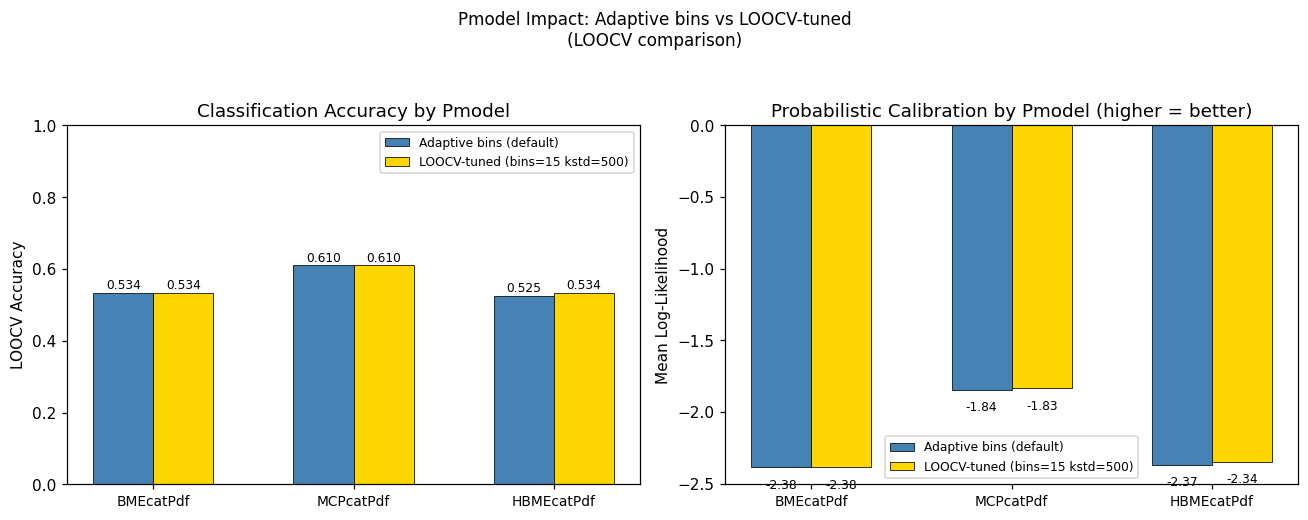

In [24]:
# ── Grouped bar chart: Adaptive vs LOOCV-tuned for all methods ────────────
methods_cmp   = ['BMEcatPdf', 'MCPcatPdf', 'HBMEcatPdf']
accs_adapt    = [acc_bme,   acc_mcp,   acc_hbme]
accs_tuned    = [acc_bme_t, acc_mcp_t, acc_hbme_t]
lls_adapt     = [ll_bme,    ll_mcp,    ll_hbme]
lls_tuned     = [ll_bme_t,  ll_mcp_t,  ll_hbme_t]

x = np.arange(len(methods_cmp))
w = 0.30

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Accuracy
ax = axes[0]
ax.bar(x - w/2, accs_adapt, width=w, label='Adaptive bins (default)',
       color='steelblue', edgecolor='k', linewidth=0.5)
ax.bar(x + w/2, accs_tuned, width=w, label=f'LOOCV-tuned ({tune_best["label"]})',
       color='gold', edgecolor='k', linewidth=0.5)
ax.set_xticks(x);  ax.set_xticklabels(methods_cmp, fontsize=9)
ax.set_ylabel('LOOCV Accuracy');  ax.set_ylim(0, 1)
ax.set_title('Classification Accuracy by Pmodel')
ax.legend(fontsize=8)
for i in range(len(methods_cmp)):
    ax.text(i - w/2, accs_adapt[i] + 0.01, f'{accs_adapt[i]:.3f}',
            ha='center', fontsize=8)
    ax.text(i + w/2, accs_tuned[i] + 0.01, f'{accs_tuned[i]:.3f}',
            ha='center', fontsize=8)

# Mean Log-Likelihood
ax = axes[1]
ax.bar(x - w/2, lls_adapt, width=w, label='Adaptive bins (default)',
       color='steelblue', edgecolor='k', linewidth=0.5)
ax.bar(x + w/2, lls_tuned, width=w, label=f'LOOCV-tuned ({tune_best["label"]})',
       color='gold', edgecolor='k', linewidth=0.5)
ax.set_xticks(x);  ax.set_xticklabels(methods_cmp, fontsize=9)
ax.set_ylabel('Mean Log-Likelihood')
ax.set_title('Probabilistic Calibration by Pmodel (higher = better)')
ax.legend(fontsize=8)
for i in range(len(methods_cmp)):
    ax.text(i - w/2, lls_adapt[i] - 0.08, f'{lls_adapt[i]:.2f}',
            ha='center', fontsize=8, va='top')
    ax.text(i + w/2, lls_tuned[i] - 0.08, f'{lls_tuned[i]:.2f}',
            ha='center', fontsize=8, va='top')

plt.suptitle('Pmodel Impact: Adaptive bins vs LOOCV-tuned\n(LOOCV comparison)',
             y=1.04, fontsize=11)
plt.tight_layout();  plt.show()

Re-running MCPcatPdf on grid with LOOCV-tuned Pmodel ...


  Done in 0.4s


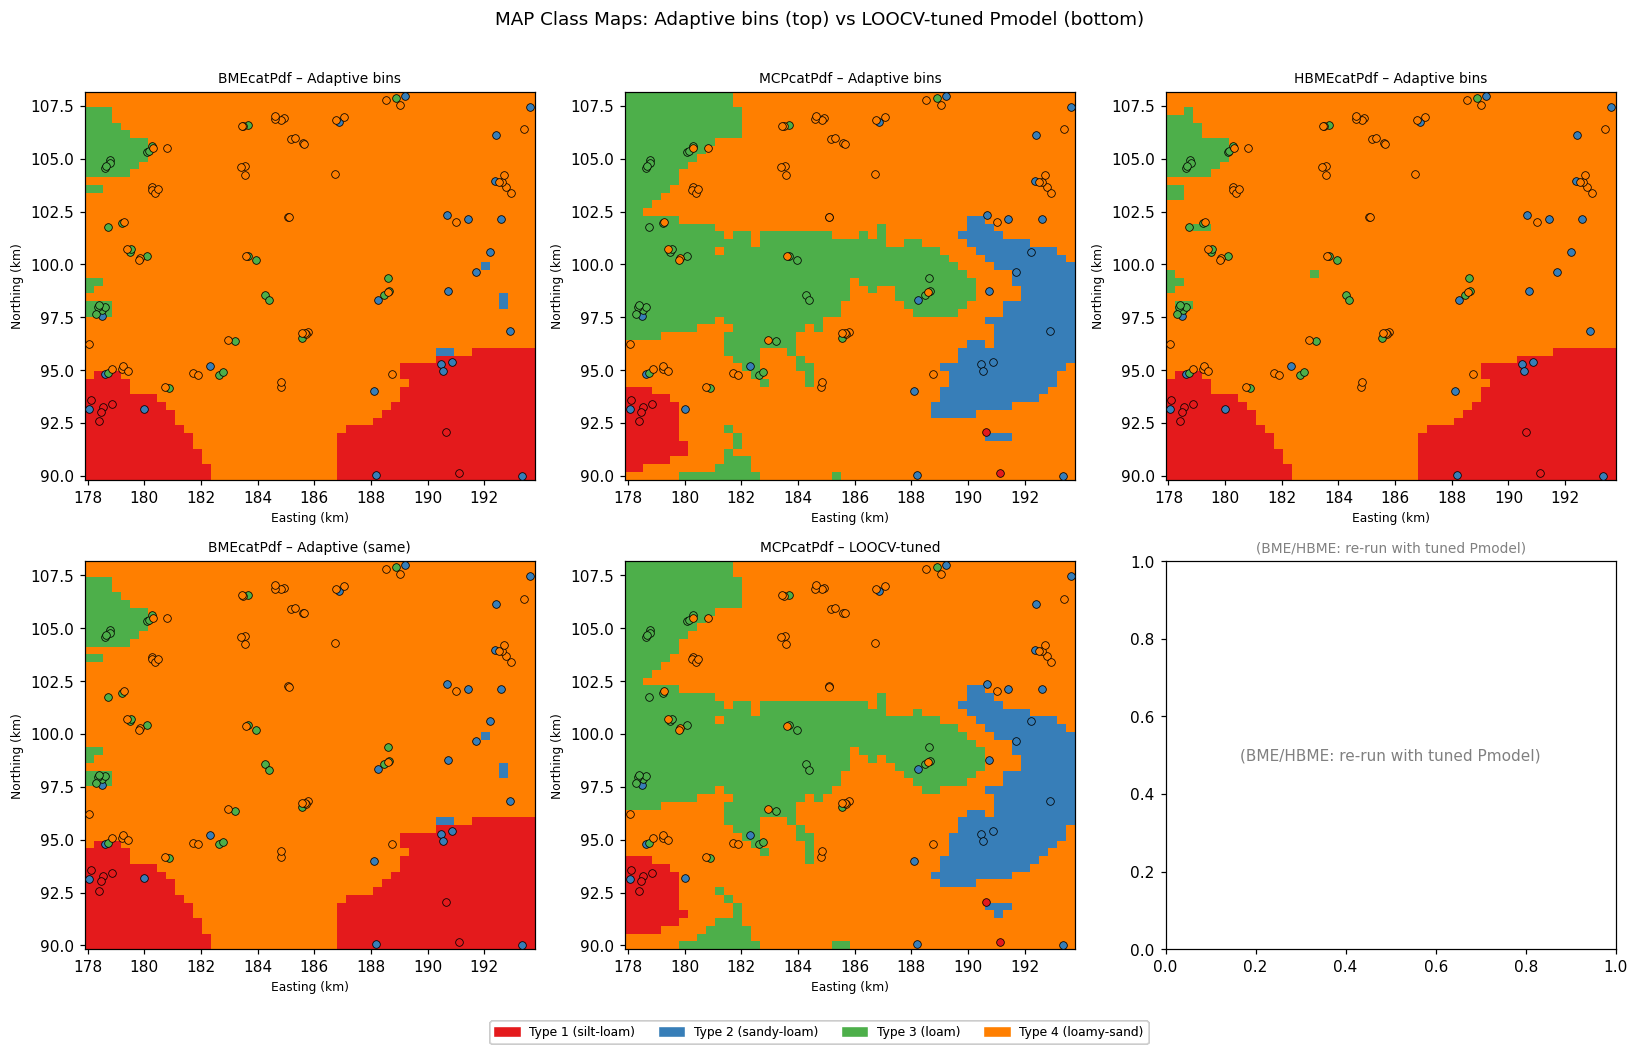


MCP MAP class changed at 36/2500 grid nodes (1.4%) when switching from adaptive to LOOCV-tuned Pmodel.


In [25]:
# ── Re-run grid estimation with LOOCV-tuned Pmodel ───────────────────────
print('Re-running MCPcatPdf on grid with LOOCV-tuned Pmodel ...')
t0 = time.perf_counter()
pk_mcp_tuned = MCPcatPdf(ck, cs, ps, dmodel_tuned, Pmodel_tuned,
                          nsmax=nsmax, dmax=dmax_bme, options=opts_quiet)
print(f'  Done in {time.perf_counter()-t0:.1f}s')

map_mcp_tuned  = categories[np.argmax(pk_mcp_tuned, axis=1)]
maxp_mcp_tuned = pk_mcp_tuned.max(axis=1)

# ── Side-by-side MAP maps: adaptive (top row) vs LOOCV-tuned (bottom row) ─
top_maps    = [map_bme,       map_mcp,       map_hbme]
top_titles  = ['BMEcatPdf – Adaptive bins',
               'MCPcatPdf – Adaptive bins',
               'HBMEcatPdf – Adaptive bins']
bot_maps    = [map_bme,  map_mcp_tuned,  None]
bot_titles  = ['BMEcatPdf – Adaptive (same)',
               'MCPcatPdf – LOOCV-tuned',
               '(BME/HBME: re-run with tuned Pmodel)']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, m, t in zip(axes[0], top_maps, top_titles):
    plot_categorical_map(XX, YY, m, t,
                         list(categories), LABELS, CMAP4,
                         cs_data=cs, code_data=code, ax=ax)
for ax, m, t in zip(axes[1], bot_maps, bot_titles):
    if m is not None:
        plot_categorical_map(XX, YY, m, t,
                             list(categories), LABELS, CMAP4,
                             cs_data=cs, code_data=code, ax=ax)
    else:
        ax.text(0.5, 0.5, t, transform=ax.transAxes,
                ha='center', va='center', fontsize=10, color='gray')
        ax.set_title(t, fontsize=9, color='gray')

fig.suptitle('MAP Class Maps: Adaptive bins (top) vs LOOCV-tuned Pmodel (bottom)',
             y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

diff_mask = map_mcp != map_mcp_tuned
n_diff = diff_mask.sum()
print(f'\nMCP MAP class changed at {n_diff}/{nk} grid nodes '
      f'({100*n_diff/nk:.1f}%) when switching from adaptive to LOOCV-tuned Pmodel.')

## 14. Per-category precision recall

We compute a simple **per-class precision and recall** from the LOOCV
predictions (MAP class vs. true class) to see which soil types are most
or least well predicted.


In [26]:
print('Computing per-class metrics for BMEcatPdf ...')
res_bme_preds = loocv_categorical_points(
    BMEcatPdf, cs, ps, dmodel, Pmodel,
    nsmax=nsmax, dmax=dmax_bme, categories=categories,
    options=base_options)

preds_bme = res_bme_preds['y_pred']
code_bme  = res_bme_preds['y_true']

# Confusion matrix (raw counts from the result dict)
cm_info = res_bme_preds['confusion_matrix']
conf_norm = cm_info['matrix']   # normalised (true)
conf = np.round(conf_norm * np.bincount(
    np.searchsorted(categories, code_bme), minlength=nc
)[:, None]).astype(int)

print('\nConfusion matrix (rows=true, cols=predicted):')
df_conf = pd.DataFrame(conf,
    index   = [f'True {c}' for c in categories],
    columns = [f'Pred {c}' for c in categories])
print(df_conf)

precision = np.diag(conf) / conf.sum(axis=0).clip(min=1)
recall    = np.diag(conf) / conf.sum(axis=1).clip(min=1)
f1_score  = 2 * precision * recall / (precision + recall).clip(min=1e-9)

df_pr = pd.DataFrame({'Category': [f'Type {c}' for c in categories],
                       'Precision': precision,
                       'Recall'   : recall,
                       'F1-score' : f1_score})
print('\nPer-class precision / recall (BMEcatPdf LOOCV):')
print(df_pr.to_string(index=False))

Computing per-class metrics for BMEcatPdf ...



Confusion matrix (rows=true, cols=predicted):
        Pred 1  Pred 2  Pred 3  Pred 4
True 1       7       0       0       0
True 2       7       0       0      17
True 3       0       0       3      29
True 4       1       0       1      53

Per-class precision / recall (BMEcatPdf LOOCV):
Category  Precision   Recall  F1-score
  Type 1   0.466667 1.000000  0.636364
  Type 2   0.000000 0.000000  0.000000
  Type 3   0.750000 0.093750  0.166667
  Type 4   0.535354 0.963636  0.688312


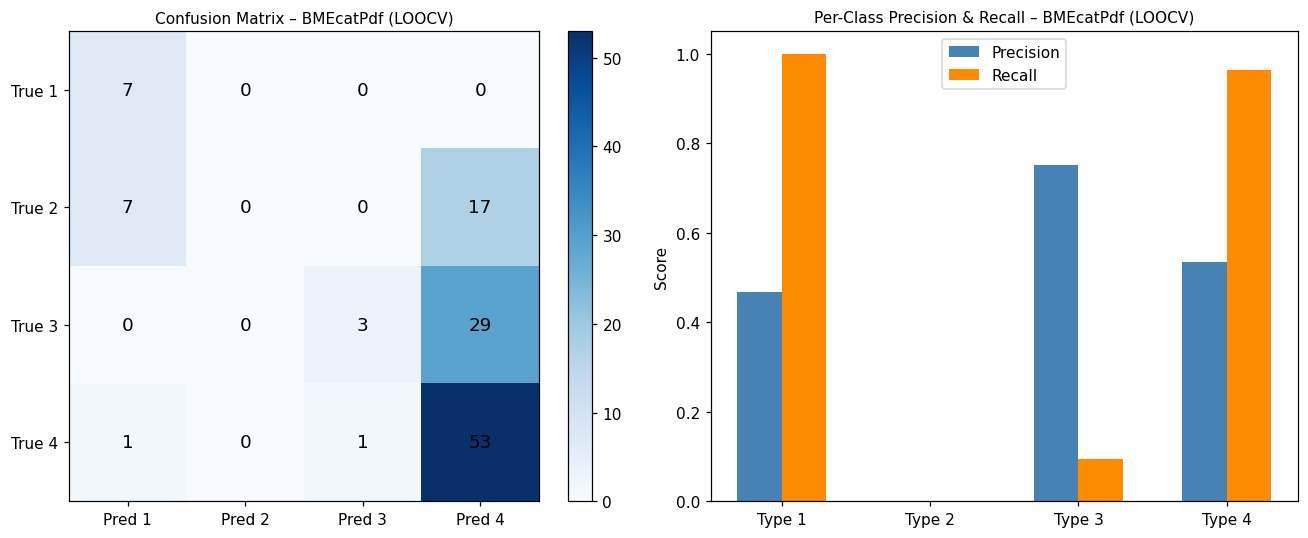

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
im = axes[0].imshow(conf, cmap='Blues', vmin=0)
for r in range(nc):
    for c_ in range(nc):
        axes[0].text(c_, r, str(conf[r, c_]),
                     ha='center', va='center', fontsize=12)
axes[0].set_xticks(range(nc));  axes[0].set_xticklabels([f'Pred {c}' for c in categories])
axes[0].set_yticks(range(nc));  axes[0].set_yticklabels([f'True {c}' for c in categories])
axes[0].set_title('Confusion Matrix – BMEcatPdf (LOOCV)', fontsize=10)
plt.colorbar(im, ax=axes[0])

# Bar chart: precision / recall
x = np.arange(nc)
w = 0.3
axes[1].bar(x - w/2, precision, width=w, label='Precision', color='steelblue')
axes[1].bar(x + w/2, recall,    width=w, label='Recall',    color='darkorange')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Type {c}' for c in categories])
axes[1].set_ylim(0, 1.05);  axes[1].set_ylabel('Score')
axes[1].set_title('Per-Class Precision & Recall – BMEcatPdf (LOOCV)', fontsize=10)
axes[1].legend()

plt.tight_layout();  plt.show()


### 14.1 Spatial distribution of LOOCV errors

Plotting the misclassified data locations reveals whether prediction errors
cluster spatially (e.g. near class boundaries or in data-sparse regions).


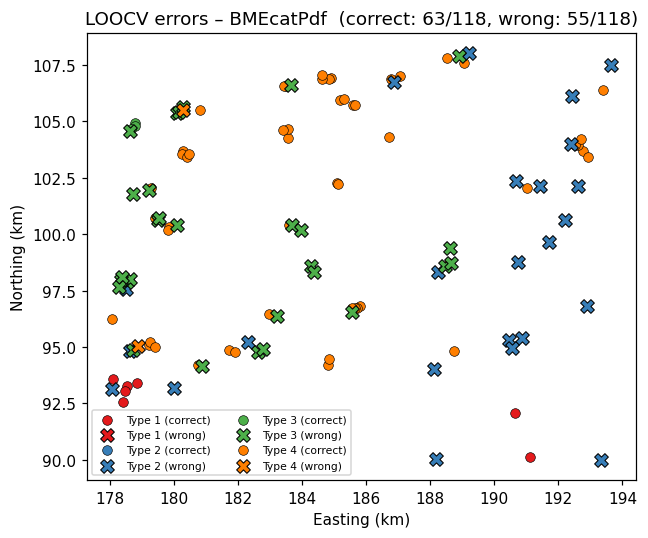

In [28]:
correct_mask   = preds_bme == code
incorrect_mask = ~correct_mask

fig, ax = plt.subplots(figsize=(6, 5))
for cat, col in zip(categories, CMAP4):
    m = code == cat
    # Correctly classified
    ax.scatter(cs[m & correct_mask,   0]/1e3,
               cs[m & correct_mask,   1]/1e3,
               c=col, s=40, edgecolors='k', linewidths=0.4,
               label=f'Type {cat} (correct)', zorder=3)
    # Misclassified (marked with 'x')
    ax.scatter(cs[m & incorrect_mask, 0]/1e3,
               cs[m & incorrect_mask, 1]/1e3,
               marker='X', c=col, s=80, edgecolors='k', linewidths=0.7,
               label=f'Type {cat} (wrong)',   zorder=4)

ax.set_xlabel('Easting (km)');  ax.set_ylabel('Northing (km)')
ax.set_title(f'LOOCV errors – BMEcatPdf  '
             f'(correct: {correct_mask.sum()}/{n}, '
             f'wrong: {incorrect_mask.sum()}/{n})')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout();  plt.show()


## 15. Sensitivity analysis – effect of `nsmax`

We use the fast **MCPcatPdf** estimator to quickly assess how the number of
neighbours influences LOOCV accuracy.


  nsmax=  2  accuracy=0.551  log-lik=-1.040
  nsmax=  4  accuracy=0.602  log-lik=-1.372
  nsmax=  6  accuracy=0.593  log-lik=-1.624
  nsmax=  8  accuracy=0.610  log-lik=-1.844


  nsmax= 12  accuracy=0.542  log-lik=-2.757
  nsmax= 16  accuracy=0.517  log-lik=-3.854


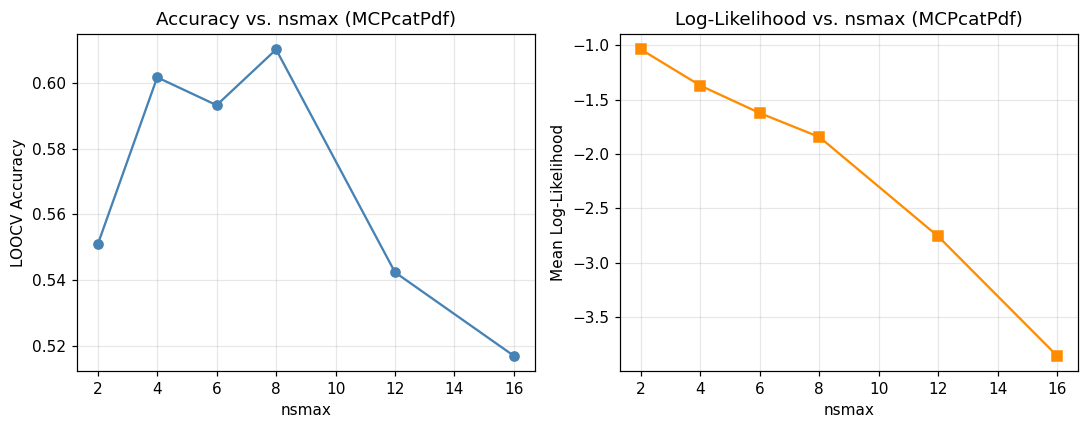

In [29]:
nsmax_grid = [2, 4, 6, 8, 12, 16]
acc_vs_ns  = []
ll_vs_ns   = []

for ns in nsmax_grid:
    res = loocv_categorical_points(
        MCPcatPdf, cs, ps, dmodel, Pmodel,
        nsmax=ns, dmax=dmax_bme, categories=categories,
        options={**base_options, 'show_progress': 0})
    acc_vs_ns.append(res['accuracy'])
    ll_vs_ns.append(res['mean_log_likelihood'])
    print(f'  nsmax={ns:3d}  accuracy={res["accuracy"]:.3f}  '
          f'log-lik={res["mean_log_likelihood"]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(nsmax_grid, acc_vs_ns, 'o-', color='steelblue')
axes[0].set_xlabel('nsmax'); axes[0].set_ylabel('LOOCV Accuracy')
axes[0].set_title('Accuracy vs. nsmax (MCPcatPdf)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(nsmax_grid, ll_vs_ns, 's-', color='darkorange')
axes[1].set_xlabel('nsmax'); axes[1].set_ylabel('Mean Log-Likelihood')
axes[1].set_title('Log-Likelihood vs. nsmax (MCPcatPdf)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 16. Summary & guidelines

### What we did

| Step | Function | Purpose |
|------|----------|---------|
| 1 | `probatablecalc` | Estimate empirical bivariate probability tables $P(c_1,c_2 \mid h)$ |
| 1b | `adaptive_bins` | Generate equal-pair (or power-law / log) distance bins for `probatablecalc` |
| 2 | `probatablefit` + `build_pmodel` | Smooth the tables with kernel regression → `Pmodel`, with pseudocount regularisation |
| 2b | `loocv_tune_pmodel` | Grid-search over binning and bandwidth to maximise LOOCV log-likelihood |
| 3 | `BMEcatPdf`      | Rigorous ME posterior, handles clustered data via ME |
| 4 | `MCPcatPdf`      | Fast approximation, good when data spacing >> correlation range |
| 5 | `HBMEcatPdf`     | Hybrid: spatially varying prior + local BME update |
| 6 | LOOCV            | Assess accuracy and probabilistic calibration |

### Practical guidelines

- **Binning strategy:** Use `adaptive_bins(method='equal_pairs')` as the
  default.  This gives more resolution at short lags and more stable
  long-range estimates.  If in doubt, try `loocv_tune_pmodel` to find the
  best `(bins, kstd)` combination objectively.
- **Probability model:** choose `kstd ≈ 0.5 × d_max_emp / n_bins`.  If the
  smoothed curves oscillate, increase `kstd` or reduce `n_bins`.
- **Regularisation:** `build_pmodel(regularize=True)` applies Empirical-Bayes
  Dirichlet pseudocounts automatically.  This prevents zero-suppression in
  rare category pairs and stabilises the ME solver.
- **Neighbourhood:** `dmax` should cover 1–2 correlation ranges.  Start with
  `nsmax = 6–10` for BMEcatPdf.
- **Estimator choice:**
  - Use **BMEcatPdf** when accuracy is paramount and runtime is acceptable.
  - Use **MCPcatPdf** for rapid exploration or large grids.
  - Use **HBMEcatPdf** when the prior matters (sparse data, strong trend).
- **Soft data:** one-hot vectors represent hard data.  If you have genuinely
  uncertain category observations (e.g. photo-interpretation), supply a
  non-trivial PMF vector in `ps`.

### Next steps

- **Prior with `BMEcatPrior`:** use XGBoost or XGBoostLSS to learn a
  spatially varying prior from ancillary covariates (DEM, satellite bands …).
- **Regularisation tuning:** use `tune_regularization_loocv` to select the
  optimal `reg` parameter for `MLE_reg` or `ME_dual` estimators.
- **Space-time extension:** add a time column to `cs` / `ck`, and extend
  `probatablecalc` to a spatio-temporal lag grid.
